# 성남시 인구 데이터 분석 (2016 – 2025)

## 이 노트북이 답하려는 질문은 **하나**입니다

> ## “성남시 인구는 10년간 7% 줄었다.
> ## 그러면 행정이 감당할 일도 줄었을까?”

**답은 “아니요”입니다.** 이유는 세 문장이면 끝납니다.

| | 발견 |
|---|---|
| **1** | 사람은 7% 줄었지만 **살림집(세대)은 오히려 4% 늘었습니다.**<br>봉투·계량기·고지서·민원은 사람마다가 아니라 **집마다** 생깁니다. |
| **2** | 그런데 그 변화의 **방향이 구마다 다릅니다.**<br>수정구는 사람은 그대로인데 집만 11% 늘었고, 중원구는 사람도 집도 줄었습니다. |
| **3** | 동으로 내려가면 **비는 동네와 차는 동네가 따로** 있습니다.<br>인구가 반토막 났다가 **예전보다 많아져서 돌아온 동네도 2곳** 있습니다. |

---

## 읽는 방법 — 렌즈를 세 번 당깁니다

이 분석은 **큰 그림에서 출발해 한 방향으로 좁혀 들어가기만** 합니다. 되돌아가지 않습니다.

```
 STEP 1.  시(市)   성남시 전체에 무슨 일이 있었나
    ↓
 STEP 2.  구(區)   그 일이 3개 구에서 똑같이 일어났나
    ↓
 STEP 3.  동(洞)   50개 동 중 정확히 어디에서 일어났나
```

각 STEP은 **항상 같은 순서**로 진행됩니다.

> **질문 → 그래프 → 💡 인사이트(한 줄 답)**

바쁘면 각 STEP의 **💡 인사이트 상자만** 읽어도 이야기가 그대로 이어집니다.
계산 방법이 궁금할 때만 그 위의 코드와 그래프를 보면 됩니다.

---

## 무엇을 가지고 분석했나

| 항목 | 내용 |
|---|---|
| **데이터** | 행정안전부 주민등록 인구통계<br>`201612_202512_주민등록인구및세대현황_연간.csv` **1개 파일** |
| **기간** | 2016년 ~ 2025년, 매년 **12월 말** 기준 (10개 연도) |
| **지역** | 성남시 1 + 3개 구(수정·중원·분당) + 50개 행정동 = **54개 행** |
| **지표** | 총인구수 · 세대수 · 세대당 인구 · 남자 인구수 · 여자 인구수 · 남여 비율 |

### 미리 알아둘 용어는 두 개뿐입니다

- **세대(世帶)** — 같이 사는 살림 단위. 혼자 살아도 1세대, 4인 가족도 1세대.
  → **세대수 ≒ 살림집 수**라고 생각하면 됩니다.
- **세대당 인구** = `총인구 ÷ 세대수`. 한 집에 평균 몇 명이 사는지.
  → 이 값이 내려간다 = **한 집에 사는 사람이 줄어든다** = 작은 가구가 많아진다.

이 두 개만 알면 아래 내용은 전부 따라올 수 있습니다.

> **분석 원칙 — 데이터에 있는 것만 말합니다.**
> 이 CSV에는 **연령·소득·주택·재개발 정보가 전혀 없습니다.** 그래서 고령화율·청년 비중처럼
> 그 자료가 있어야 나오는 결론은 내리지 않았습니다. 말할 수 없는 것은 마지막
> **[한계]** 절에 그대로 적어 두었습니다. 방법론 세부 검사는 **[부록]** 으로 뺐습니다.

---
# 0. 준비 — 라이브러리 · 한글 폰트 · 색 규칙

세 가지를 한 번에 준비합니다.

1. **라이브러리** — 계산은 `pandas`·`numpy`, 그림은 `matplotlib`
2. **한글 폰트** — 안 하면 그래프의 한글이 전부 `□□□` 로 깨집니다
3. **색 규칙** — 색을 그때그때 고르지 않고 **역할별로 미리 정해** 끝까지 그 역할로만 씁니다
   (특히 **구 색깔은 이 노트북 어디서나 같습니다** — 🔵수정구 🟠중원구 🟢분당구)

In [1]:
import re
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc

# ── 1) 한글 폰트 ─────────────────────────────────────────────
plt.rcParams['axes.unicode_minus'] = False          # 마이너스 기호 깨짐 방지
if platform.system() == 'Linux':     rc('font', family='NanumGothic')
elif platform.system() == 'Windows': rc('font', family='Malgun Gothic')
else:                                rc('font', family='AppleGothic')

# ── 2) 색 규칙 ───────────────────────────────────────────────
SURFACE, INK, INK2, MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#898781'
GRID, AXIS = '#e1e0d9', '#c3c2b7'

C1, C2, C3 = '#2a78d6', '#eb6834', '#1baf7a'          # 구 고정 색
GU_ORDER = ['수정구', '중원구', '분당구']
GU_COLOR = dict(zip(GU_ORDER, [C1, C2, C3]))
POS, NEG = '#2a78d6', '#e34948'                        # 증가 / 감소

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': INK2,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'text.color': INK, 'axes.titlecolor': INK,
    'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.grid': False,
    'font.size': 11, 'figure.dpi': 110,
})

# ── 3) 그래프 공통 서식 ──────────────────────────────────────
def style(ax, title=None, sub=None, xlab=None, ylab=None, grid='y'):
    """제목·부제·축을 한 번에 정리한다."""
    if title:
        ax.set_title(title, fontsize=14, color=INK, loc='left', pad=32 if sub else 12)
    if sub:
        ax.annotate(sub, xy=(0, 1), xycoords='axes fraction', xytext=(0, 9),
                    textcoords='offset points', fontsize=10.5, color=INK2, va='bottom')
    ax.set_xlabel(xlab or '', fontsize=10.5, color=INK2)
    ax.set_ylabel(ylab or '', fontsize=10.5, color=INK2)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(AXIS); ax.spines[s].set_linewidth(0.8)
    if grid in ('y', 'both'): ax.grid(axis='y', color=GRID, linewidth=0.8, zorder=0)
    if grid in ('x', 'both'): ax.grid(axis='x', color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    return ax

print('준비 완료 · 폰트:', plt.rcParams['font.family'][0])

준비 완료 · 폰트: NanumGothic


---
# 1. 데이터 만들기

원본 CSV를 그대로 쓸 수는 없습니다. **손봐야 할 곳이 두 군데** 있습니다.

**① 한 열에 시·구·동이 섞여 있습니다.**

```
경기도 경기도 성남시 (4113000000)        ← 시
경기도 경기도 성남시 수정구 (4113100000)  ← 구
경기도 성남시 수정구 신흥1동(4113151000)  ← 동
```

성남시 행에도, 수정구 행에도, 신흥1동 행에도 **같은 사람이 들어 있습니다.**
그래서 그냥 `sum()` 하면 **같은 사람을 세 번 셉니다.**
→ `레벨`(시/구/동) 열을 만들어 **분석할 때마다 한 층위만** 골라 씁니다.

**② 연도가 열 이름 속에 숨어 있습니다.**

```
[바꾸기 전]  구      2016년_총인구수  2017년_총인구수  …   ← 가로로 60개 열
[바꾼 후]    구      연도    총인구수                      ← 연도가 값이 된다
             수정구  2016     232,841
             수정구  2017     236,932
```

이렇게 바꿔 두면 `groupby('연도')` 나 선 그래프가 훨씬 단순해집니다.

> **읽을 때 옵션 두 개는 필수입니다.**
> `encoding='cp949'` — 행안부 CSV는 EUC-KR 계열이라 없으면 한글이 깨집니다.
> `thousands=','` — 없으면 `"974,580"` 이 **글자**로 읽혀 계산이 전부 불가능해집니다.

In [2]:
YEARS = list(range(2016, 2026))
METRICS = ['총인구수', '세대수', '세대당 인구', '남자 인구수', '여자 인구수', '남여 비율']

raw = pd.read_csv('population_data/201612_202512_주민등록인구및세대현황_연간.csv',
                  encoding='cp949', thousands=',')

# ① 시/구/동 층위 분리 ------------------------------------------------
def parse_region(s):
    """'경기도 경기도 성남시 수정구 (4113100000)' → ('구', '수정구', None)"""
    name = re.sub(r'\s*\(\d+\)\s*$', '', s).strip()      # 뒤쪽 (지역코드) 제거
    parts = [p for p in name.split() if p != '경기도']    # '경기도 경기도' 중복 제거
    if len(parts) == 1: return ('시', '성남시', None)
    if len(parts) == 2: return ('구', parts[1], None)
    return ('동', parts[1], parts[2])

meta = pd.DataFrame([parse_region(s) for s in raw['행정구역']], columns=['레벨', '구', '동'])
df = pd.concat([meta, raw.drop(columns=['행정구역'])], axis=1)   # wide 형태 (연도=열)

# ② wide → long 변환 (연도를 값으로) -----------------------------------
long = pd.concat(
    [df[['레벨', '구', '동']].assign(연도=y, **{m: df[f'{y}년_{m}'].values for m in METRICS})
     for y in YEARS],
    ignore_index=True).sort_values(['레벨', '구', '동', '연도'])

print('원본 :', raw.shape, '(행=지역, 열=행정구역 + 10년 × 6지표)')
print('층위 :', df['레벨'].value_counts().reindex(['시', '구', '동']).to_dict())
print('long :', long.shape, '= 54개 지역 × 10개 연도')
print('결측 :', raw.isna().sum().sum(), '개')

# 연도가 '값'이 된 것을 눈으로 확인 (수정구 3개 연도)
long[(long.레벨 == '구') & (long.구 == '수정구')].head(3)[['레벨', '구', '연도', '총인구수', '세대수', '세대당 인구']]

원본 : (54, 61) (행=지역, 열=행정구역 + 10년 × 6지표)
층위 : {'시': 1, '구': 3, '동': 50}
long : (540, 10) = 54개 지역 × 10개 연도
결측 : 0 개


,레벨,구,연도,총인구수,세대수,세대당 인구
1,구,수정구,2016,232841,104855,2.22
55,구,수정구,2017,236932,107823,2.20
109,구,수정구,2018,234133,108396,2.16


### 분석 전 마지막 확인 — 이 데이터를 믿어도 되나

숫자가 서로 어긋나 있는데 그 위에 그래프를 그리면 **예쁘지만 틀린 결론**이 나옵니다.
그래서 세 가지만 확인합니다. 셋 다 `PASS` 면 **결측 처리·이상치 보정 없이 원본 값을 그대로** 씁니다.

| # | 확인할 것 | 왜 |
|---|---|---|
| 1 | 남자 + 여자 = 총인구 | 가장 기본적인 항등식. 틀리면 원본이 손상된 것 |
| 2 | 총인구 ÷ 세대수 = 세대당 인구 | 이 분석의 **핵심 지표**가 정말 그 정의대로인지 |
| 3 | 동 합계 = 구 합계 = 시 값 (10개 연도 전부) | 이게 맞아야 “동 결과를 더하면 시 전체”라고 말할 수 있음 |

In [3]:
checks = []

gap = (long['남자 인구수'] + long['여자 인구수'] - long['총인구수']).abs()
checks.append(('남자+여자 = 총인구', gap.max() == 0, f'최대 오차 {gap.max()}'))

d2 = ((long['총인구수'] / long['세대수']).round(2) - long['세대당 인구']).abs()
checks.append(('총인구/세대수 = 세대당 인구', d2.max() <= 0.01, f'최대 오차 {d2.max():.3f}'))

ok = all(long[(long.레벨 == '시') & (long.연도 == y)]['총인구수'].iloc[0]
         == long[(long.레벨 == '구') & (long.연도 == y)]['총인구수'].sum()
         == long[(long.레벨 == '동') & (long.연도 == y)]['총인구수'].sum() for y in YEARS)
checks.append(('동합 = 구합 = 시 (10개 연도)', ok, '전 구간 일치' if ok else '불일치 발견'))

for name, passed, note in checks:
    print(f"[{'PASS' if passed else 'FAIL'}] {name:<28} {note}")

[PASS] 남자+여자 = 총인구                  최대 오차 0
[PASS] 총인구/세대수 = 세대당 인구             최대 오차 0.000
[PASS] 동합 = 구합 = 시 (10개 연도)         전 구간 일치


---
---
# STEP 1. 시(市) — 사람은 줄고, 집은 늘었다

> ## 질문. 인구가 줄었으면, 살림집도 같이 줄었을까?

가장 큰 그림부터 봅니다. 그런데 그리기 전에 문제가 하나 있습니다.

**총인구는 약 90만, 세대수는 약 41만** 으로 단위가 다릅니다. 한 그래프에 겹치면 **세로축이 두 개**가 되고,
그러면 눈금을 어떻게 맞추느냐에 따라 **두 선이 만나는 지점이 마음대로 바뀝니다.**
없는 관계를 있는 것처럼 보이게 만들 수 있습니다.

→ 그래서 **2016년을 똑같이 100으로 놓고** 그 뒤 몇이 됐는지로 바꿔 그립니다(**지수화**). 축 하나로 정직하게 비교됩니다.

**그리고 “왜 늘었나”까지 한 번에 봅니다.** 세대수에는 **반대 방향의 두 힘**이 섞여 있습니다.

```
① 인구 효과      인구가 줄어서 세대가 줄어드는 힘   (−)
② 가구 축소 효과  한 집당 사람이 줄어서 세대가 느는 힘 (+)

  가상 세대수 = 2025년 인구 ÷ 2016년 세대당 인구   ← "한 집당 사람 수가 그대로였다면 필요했을 집"
  ① = 가상 세대수 − 2016년 실제 세대수
  ② = 2025년 실제 세대수 − 가상 세대수
  ① + ② = 실제 세대수 증감
```

In [4]:
city = long[long.레벨 == '시'].set_index('연도')
pop, hh, hs = city['총인구수'], city['세대수'], city['세대당 인구']

# 2016년 = 100 으로 지수화
idx = pd.DataFrame({m: city[m] / city[m].loc[2016] * 100 for m in ['총인구수', '세대수', '세대당 인구']})

# 세대수 증감을 두 힘으로 분해
#   CSV의 '세대당 인구'(2.47)는 소수 2자리 반올림 표시값 → 계산에는 반올림 전 값을 쓴다
hs_2016 = pop.loc[2016] / hh.loc[2016]
가상세대수 = pop / hs_2016
인구효과 = 가상세대수.loc[2025] - hh.loc[2016]      # (−)
가구효과 = hh.loc[2025] - 가상세대수.loc[2025]      # (+)

print(f'① 인구가 줄어서 줄어든 세대   : {인구효과:>+10,.0f} 세대')
print(f'② 집이 작아져서 늘어난 세대   : {가구효과:>+10,.0f} 세대')
print( '  ' + '─' * 38)
print(f'   실제 세대수 증감 (① + ②)   : {인구효과 + 가구효과:>+10,.0f} 세대\n')

summary = pd.DataFrame({'2016': [pop.loc[2016], hh.loc[2016], hs.loc[2016]],
                        '2025': [pop.loc[2025], hh.loc[2025], hs.loc[2025]]},
                       index=['총인구수', '세대수', '세대당 인구'])
summary['증감'] = summary['2025'] - summary['2016']
summary['변화율(%)'] = (summary['2025'] / summary['2016'] - 1) * 100
summary.round(2)

① 인구가 줄어서 줄어든 세대   :    -27,815 세대
② 집이 작아져서 늘어난 세대   :    +42,980 세대
  ──────────────────────────────────────
   실제 세대수 증감 (① + ②)   :    +15,165 세대



,2016,2025,증감,변화율(%)
총인구수,974580.00,905794.00,-68786.00,-7.06
세대수,394087.00,409252.00,15165.00,3.85
세대당 인구,2.47,2.21,-0.26,-10.53


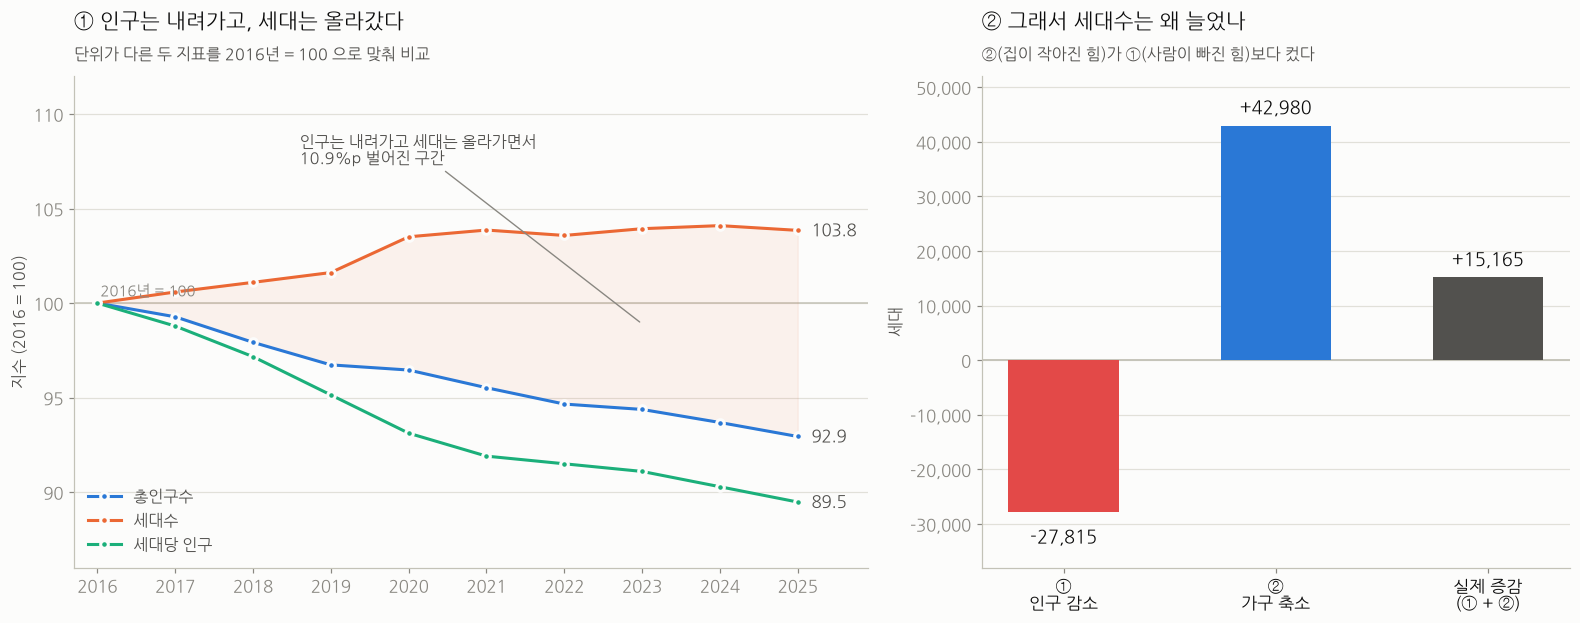

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.8), gridspec_kw={'width_ratios': [1.35, 1]})

# ── 왼쪽: 2016년 = 100 지수 추이 ─────────────────────────────
ax = axes[0]
for name, color in [('총인구수', C1), ('세대수', C2), ('세대당 인구', C3)]:
    ax.plot(idx.index, idx[name], color=color, linewidth=2, marker='o', markersize=5,
            markeredgecolor=SURFACE, markeredgewidth=2, label=name, zorder=3)
    ax.annotate(f'{idx[name].iloc[-1]:.1f}', (2025, idx[name].iloc[-1]), xytext=(9, 0),
                textcoords='offset points', va='center', fontsize=11, color=INK2)

ax.axhline(100, color=AXIS, linewidth=1, zorder=1)
ax.annotate('2016년 = 100', (2016, 100), xytext=(2, 5), textcoords='offset points',
            fontsize=9.5, color=MUTED)
ax.fill_between(idx.index, idx['총인구수'], idx['세대수'], color=C2, alpha=0.07, zorder=1)
ax.annotate('인구는 내려가고 세대는 올라가면서\n10.9%p 벌어진 구간', xy=(2023.0, 98.9),
            xytext=(2018.6, 107.4), fontsize=10.5, color=INK2,
            arrowprops=dict(arrowstyle='-', color=MUTED, linewidth=0.9, shrinkB=2))

style(ax, '① 인구는 내려가고, 세대는 올라갔다', '단위가 다른 두 지표를 2016년 = 100 으로 맞춰 비교',
      ylab='지수 (2016 = 100)')
ax.set_xticks(YEARS); ax.set_xlim(2015.7, 2025.9); ax.set_ylim(86, 112)
ax.legend(frameon=False, loc='lower left', fontsize=10.5, labelcolor=INK2)

# ── 오른쪽: 세대수 증감을 두 힘으로 분해 ─────────────────────
ax = axes[1]
bars = [('①\n인구 감소', 인구효과, NEG), ('②\n가구 축소', 가구효과, POS),
        ('실제 증감\n(① + ②)', 인구효과 + 가구효과, INK2)]
for i, (lab, v, c) in enumerate(bars):
    ax.bar(i, v, width=0.52, color=c, zorder=3)
    ax.annotate(f'{v:+,.0f}', (i, v), xytext=(0, 8 if v > 0 else -20),
                textcoords='offset points', ha='center', fontsize=11.5, color=INK)
ax.axhline(0, color=AXIS, linewidth=1.2, zorder=2)
ax.set_xticks(range(3)); ax.set_xticklabels([b[0] for b in bars], fontsize=11, color=INK)
ax.set_ylim(-38000, 52000)
ax.yaxis.set_major_formatter(lambda v, p: f'{v:,.0f}')
style(ax, '② 그래서 세대수는 왜 늘었나', '②(집이 작아진 힘)가 ①(사람이 빠진 힘)보다 컸다', ylab='세대')

plt.tight_layout(); plt.show()

> ## 💡 인사이트 ① — 인구는 줄었지만, 행정이 감당할 일은 늘었다
>
> | 지표 | 2016 → 2025 | 변화 |
> |---|---|---|
> | 🔵 **총인구** | 974,580명 → 905,794명 | **−68,786명 (−7.06%)** — 10년 내내 단 한 번도 오르지 않음 |
> | 🟠 **세대수** | 394,087세대 → 409,252세대 | **+15,165세대 (+3.85%)** — 오히려 늘어남 |
> | 🟢 **세대당 인구** | 2.47명 → 2.21명 | **−0.26명** — 한 집에 사는 사람이 줄었다 |
>
> 인구가 주는데 세대가 느는 건 **모순이 아닙니다.** 한 집에 사는 사람이 줄면
> **같은 인구라도 더 많은 집이 필요**해집니다. 오른쪽 그래프가 그 크기를 보여줍니다.
>
> - ① 인구가 빠져서 **줄어든** 세대 **−27,815**
> - ② 집이 작아져서 **늘어난** 세대 **+42,980** ← 이쪽이 더 크다
> - 합계 **+15,165세대**
>
> **➡️ 쓰레기봉투·수도 계량기·고지서·주민센터 민원은 사람 한 명마다가 아니라 집 한 채마다 생깁니다.
> 인구는 7% 줄었지만, 세대 단위로 생기는 행정 수요는 4% 늘었습니다.**
>
> ⚠️ 한 집당 사람 수가 줄어든 **원인**(가족이 쪼개졌는지, 1인 가구가 들어왔는지)은
> 이 데이터로 구분할 수 없습니다. 여기서는 **“줄었다”는 사실만** 씁니다.

---
---
# STEP 2. 구(區) — 그 변화는 구마다 방향이 다르다

> ## 질문. STEP 1의 결론(“인구 ↓, 세대 ↑”)을 세 구에 그대로 적용해도 될까?

시 전체 평균 **−7.06%** 를 정책 근거로 쓰기 전에 **반드시** 확인할 것이 있습니다.
**3개 구가 정말 같은 방향으로 가고 있는가?**

결론부터 말하면 — **전혀 아닙니다.**

In [6]:
gu = long[long.레벨 == '구'].copy()
w = gu.pivot_table(index='구', columns='연도', values=['총인구수', '세대수', '세대당 인구'])

tbl = pd.DataFrame({
    '인구 증감':      w[('총인구수', 2025)] - w[('총인구수', 2016)],
    '인구 변화율(%)': (w[('총인구수', 2025)] / w[('총인구수', 2016)] - 1) * 100,
    '세대 증감':      w[('세대수',   2025)] - w[('세대수',   2016)],
    '세대 변화율(%)': (w[('세대수',   2025)] / w[('세대수',   2016)] - 1) * 100,
    '세대당 2016':    w[('세대당 인구', 2016)],
    '세대당 2025':    w[('세대당 인구', 2025)],
}).loc[GU_ORDER]
# 시 전체 감소분(-68,786명) 중 이 구가 만들어낸 몫
tbl['시 감소 기여(%)'] = (w[('총인구수', 2016)] - w[('총인구수', 2025)]) / (pop.loc[2016] - pop.loc[2025]) * 100
tbl.round(2)

,인구 증감,인구 변화율(%),세대 증감,세대 변화율(%),세대당 2016,세대당 2025,시 감소 기여(%)
구,,,,,,,
수정구,-452.0,-0.19,11345.0,10.82,2.22,2.00,0.66
중원구,-34337.0,-14.43,-1678.0,-1.66,2.35,2.04,49.92
분당구,-33997.0,-6.75,5498.0,2.93,2.68,2.43,49.42


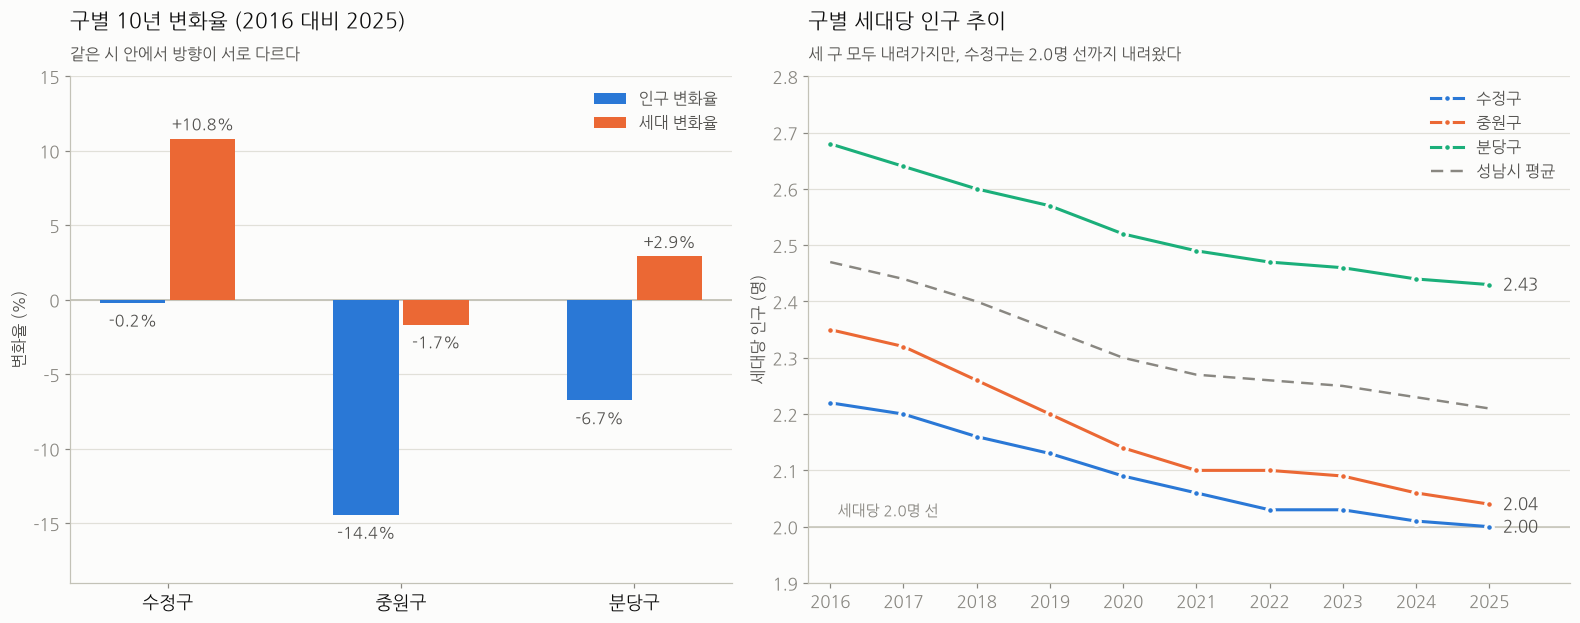

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.8), gridspec_kw={'width_ratios': [1, 1.15]})

# ── 왼쪽: 인구 변화율 vs 세대 변화율 ─────────────────────────
ax = axes[0]
x, wdt = np.arange(3), 0.28
for offset, col, color, lab in [(-wdt/2 - 0.01, '인구 변화율(%)', C1, '인구 변화율'),
                                (+wdt/2 + 0.01, '세대 변화율(%)', C2, '세대 변화율')]:
    vals = tbl[col].values
    ax.bar(x + offset, vals, wdt, color=color, label=lab, zorder=3)
    for xi, v in zip(x + offset, vals):
        ax.annotate(f'{v:+.1f}%', (xi, v), xytext=(0, -15 if v < 0 else 6),
                    textcoords='offset points', ha='center', fontsize=10.5, color=INK2)

ax.axhline(0, color=AXIS, linewidth=1.2, zorder=2)
ax.set_xticks(x); ax.set_xticklabels(GU_ORDER, fontsize=12, color=INK)
ax.set_ylim(-19, 15)
style(ax, '구별 10년 변화율 (2016 대비 2025)', '같은 시 안에서 방향이 서로 다르다', ylab='변화율 (%)')
ax.legend(frameon=False, loc='upper right', fontsize=10.5, labelcolor=INK2)

# ── 오른쪽: 세대당 인구 추이 ─────────────────────────────────
ax = axes[1]
for g in GU_ORDER:
    s = gu[gu.구 == g].set_index('연도')['세대당 인구']
    ax.plot(s.index, s.values, color=GU_COLOR[g], linewidth=2, marker='o', markersize=5,
            markeredgecolor=SURFACE, markeredgewidth=2, label=g, zorder=3)
    ax.annotate(f'{s.iloc[-1]:.2f}', (2025, s.iloc[-1]), xytext=(9, 0),
                textcoords='offset points', va='center', fontsize=11, color=INK2)
ax.plot(hs.index, hs.values, color=MUTED, linewidth=1.6, linestyle=(0, (5, 3)),
        label='성남시 평균', zorder=2)
ax.axhline(2.0, color=AXIS, linewidth=1, zorder=1)
ax.annotate('세대당 2.0명 선', (2016.1, 2.02), fontsize=9.5, color=MUTED)

style(ax, '구별 세대당 인구 추이', '세 구 모두 내려가지만, 수정구는 2.0명 선까지 내려왔다',
      ylab='세대당 인구 (명)')
ax.set_xticks(YEARS); ax.set_xlim(2015.7, 2026.1); ax.set_ylim(1.9, 2.8)
ax.legend(frameon=False, loc='upper right', fontsize=10.5, labelcolor=INK2)

plt.tight_layout(); plt.show()

> ## 💡 인사이트 ② — 한 도시 안에서 세 가지 다른 일이 벌어지고 있다
>
> | 구 | 인구 | 세대 | 무슨 일인가 |
> |---|---|---|---|
> | 🔵 **수정구** | **−0.19%**<br>(−452명) | **+10.82%**<br>(+11,345세대) | **사람은 그대로인데 집만 11% 늘었다**<br>한 집에 2.00명 — 시에서 가장 낮음 |
> | 🟠 **중원구** | **−14.43%**<br>(−34,337명) | **−1.66%**<br>(−1,678세대) | **사람도 집도 함께 줄었다**<br>시 인구 감소분의 **49.9%** |
> | 🟢 **분당구** | **−6.75%**<br>(−33,997명) | **+2.93%**<br>(+5,498세대) | 사람은 줄고 집은 느는 **중간형**<br>감소분의 **49.4%** |
>
> **1️⃣ 성남시가 잃은 68,786명은 사실상 중원구와 분당구가 정확히 반씩 만들어냈습니다.**
> 수정구의 기여는 **0.7%** 에 불과합니다.
>
> **2️⃣ 세대 증감의 방향이 서로 반대입니다** (수정 ↑ · 중원 ↓ · 분당 ↑).
>
> **➡️ 그래서 시 평균 하나로는 어느 구의 정책 근거도 되지 못합니다.**
> 수정구에 “인구가 줄었으니 행정을 줄이자”를 적용하면 **11% 늘어난 수요를 통째로 놓칩니다.**

---
---
# STEP 3. 동(洞) — 비는 동네와 차는 동네

> ## 질문. 구 단위로도 아직 부족하다. **예산과 시설은 동 단위로 배치**되기 때문이다.
> ## 그러면 50개 동 중 정확히 어디에서 무슨 일이 있었나?

마지막 STEP은 질문이 셋이라 **세 개의 소절**로 나눠 봅니다.

| 소절 | 질문 |
|---|---|
| **3-1** | 어디가 비고, 어디가 찼나? |
| **3-2** | 인구가 반토막 난 동네 — 그건 **쇠퇴인가, 잠깐 빈 것인가?** |
| **3-3** | 한 집당 사람이 가장 적은 곳은 어디인가? |

## 3-1. 50개 동을 네 유형으로 나누기

동을 나눌 때 `"−15% 아래면 쇠퇴"` 같은 **임의의 기준선은 위험합니다.** 기준을 −10%로 바꾸는 순간 결론도 바뀝니다.
그래서 **누구도 시비를 걸 수 없는 기준, 0%(늘었나 줄었나) 두 개만** 씁니다.

`인구가 늘었나/줄었나` × `세대가 늘었나/줄었나` → **네 칸**이 나옵니다.

| | **세대 증가 ↑** | **세대 감소 ↓** |
|---|---|---|
| **인구 증가 ↑** | 🟢 **신규 유입형** — 사람도 집도 늘었다 | ⚪ **가구 통합형** — 사람은 느는데 집은 줄었다 |
| **인구 감소 ↓** | 🟡 **가구 분화형** — 사람은 줄었는데 집은 늘었다 | 🔴 **동반 축소형** — 사람도 집도 줄었다 |

In [8]:
dong = df[df.레벨 == '동'].copy()
for k, src in [('인구', '총인구수'), ('세대', '세대수'), ('세대당', '세대당 인구')]:
    dong[f'{k}2016'] = dong[f'2016년_{src}']
    dong[f'{k}2025'] = dong[f'2025년_{src}']
    dong[f'{k}증감']  = dong[f'{k}2025'] - dong[f'{k}2016']
dong['인구변화율'] = (dong['인구2025'] / dong['인구2016'] - 1) * 100
dong['세대변화율'] = (dong['세대2025'] / dong['세대2016'] - 1) * 100

def classify(r):
    if r['인구변화율'] >= 0 and r['세대변화율'] >= 0: return '신규유입형'
    if r['인구변화율'] <  0 and r['세대변화율'] >= 0: return '가구분화형'
    if r['인구변화율'] <  0 and r['세대변화율'] <  0: return '동반축소형'
    return '가구통합형'

dong['유형'] = dong.apply(classify, axis=1)
dong = dong[['구', '동', '인구2016', '인구2025', '인구증감', '인구변화율',
             '세대2016', '세대2025', '세대증감', '세대변화율',
             '세대당2016', '세대당2025', '세대당증감', '유형']].reset_index(drop=True)

print(dong.groupby('유형').agg(동수=('동', 'count'), 인구증감=('인구증감', 'sum'),
                               세대증감=('세대증감', 'sum')).sort_values('동수', ascending=False).to_string(), '\n')
print(pd.crosstab(dong['구'], dong['유형']).reindex(GU_ORDER).to_string())

       동수    인구증감   세대증감
유형                      
동반축소형  31 -120774 -22634
가구분화형  11  -16203   5056
신규유입형   8   68191  32743 

유형   가구분화형  동반축소형  신규유입형
구                       
수정구      2     11      4
중원구      2      7      2
분당구      7     13      2


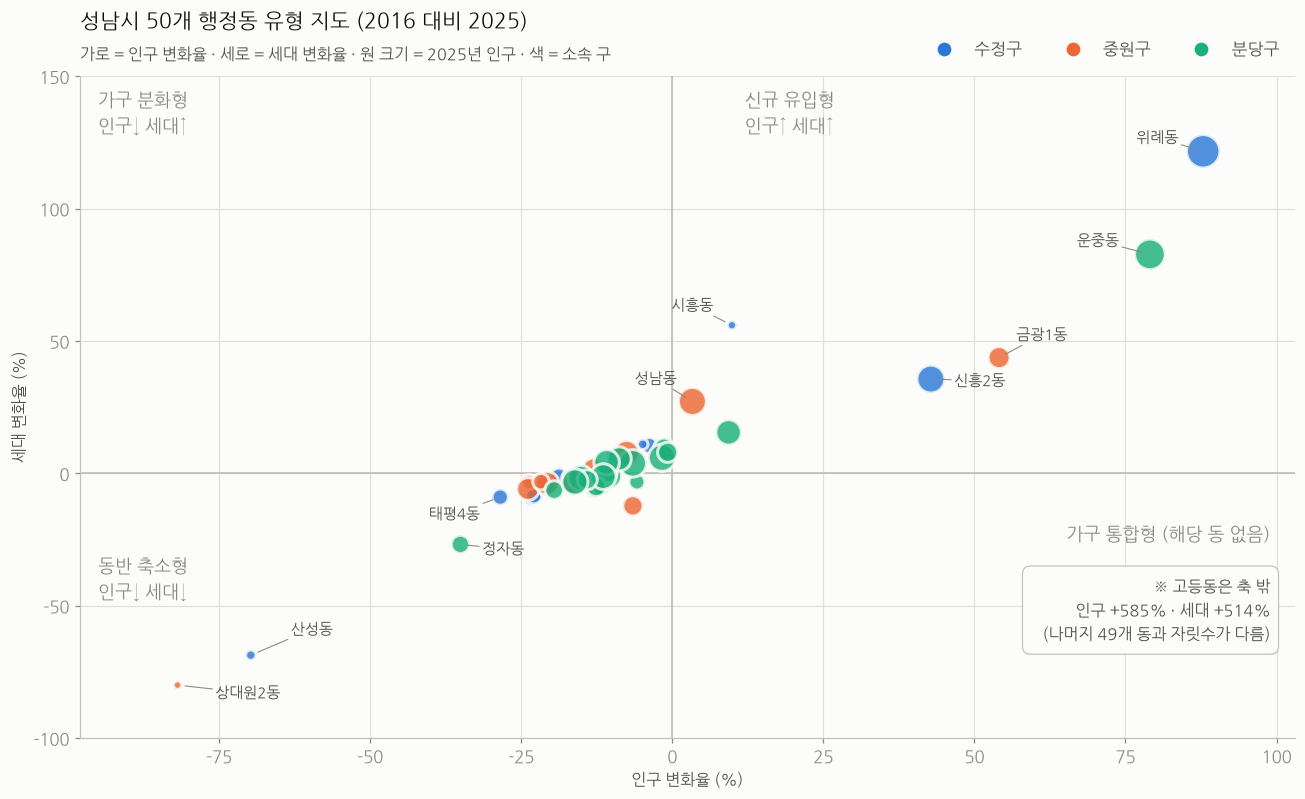

In [9]:
fig, ax = plt.subplots(figsize=(12, 7.4))
XMAX, YMIN, YMAX = 100, -100, 150

ax.axvline(0, color=AXIS, linewidth=1.2, zorder=2)
ax.axhline(0, color=AXIS, linewidth=1.2, zorder=2)

inside = dong[dong['인구변화율'] <= XMAX]
for g in GU_ORDER:
    s = inside[inside.구 == g]
    ax.scatter(s['인구변화율'], s['세대변화율'], s=s['인구2025'] / 95, color=GU_COLOR[g],
               alpha=0.82, linewidths=2, edgecolors=SURFACE, label=g, zorder=3)

# 4분면 이름 — 각 이름은 자기 분면 안, 점이 없는 자리에 둔다
for tx, ty, txt, ha in [(-95, YMAX - 4, '가구 분화형\n인구↓ 세대↑', 'left'),
                        ( 12, YMAX - 4, '신규 유입형\n인구↑ 세대↑', 'left'),
                        (-95, -30,      '동반 축소형\n인구↓ 세대↓', 'left'),
                        ( 99, -18,      '가구 통합형 (해당 동 없음)', 'right')]:
    ax.text(tx, ty, txt, fontsize=11.5, color=MUTED, ha=ha, va='top', linespacing=1.5, zorder=2)

# 축 밖으로 나가는 단 하나의 동은 위치로 그리지 않고 글로 적는다
out = dong[dong['인구변화율'] > XMAX]
for _, r in out.iterrows():
    ax.text(99, -38, f"※ {r['동']}은 축 밖\n   인구 {r['인구변화율']:+.0f}% · 세대 {r['세대변화율']:+.0f}%\n"
                     f"   (나머지 49개 동과 자릿수가 다름)",
            fontsize=10.5, color=INK2, ha='right', va='top', linespacing=1.5, zorder=4,
            bbox=dict(boxstyle='round,pad=0.5', facecolor=SURFACE, edgecolor=AXIS, linewidth=0.8))

# 극단값에만 이름표 — 모든 점에 라벨을 붙이지 않는다
labels = {'위례동': (-30, 6), '운중동': (-34, 6), '금광1동': (28, 12), '신흥2동': (32, -4),
          '시흥동': (-26, 10), '성남동': (-24, 12), '상대원2동': (46, -8), '산성동': (40, 14),
          '정자동': (28, -6), '태평4동': (-30, -14)}
for _, r in dong.iterrows():
    if r['동'] in labels:
        ax.annotate(r['동'], (r['인구변화율'], r['세대변화율']), xytext=labels[r['동']],
                    textcoords='offset points', fontsize=10, color=INK2, ha='center', zorder=5,
                    arrowprops=dict(arrowstyle='-', color=MUTED, linewidth=0.7, shrinkA=0, shrinkB=5))

ax.set_xlim(-98, 103); ax.set_ylim(YMIN, YMAX)
style(ax, '성남시 50개 행정동 유형 지도 (2016 대비 2025)',
      '가로 = 인구 변화율 · 세로 = 세대 변화율 · 원 크기 = 2025년 인구 · 색 = 소속 구',
      xlab='인구 변화율 (%)', ylab='세대 변화율 (%)', grid='both')
ax.legend(handles=[plt.Line2D([], [], marker='o', linestyle='', markersize=11, color=GU_COLOR[g],
                              markeredgecolor=SURFACE, markeredgewidth=2, label=g) for g in GU_ORDER],
          frameon=False, loc='lower right', bbox_to_anchor=(1.0, 1.005), ncol=3,
          fontsize=11, labelcolor=INK2)
plt.tight_layout(); plt.show()

> ## 💡 인사이트 ③ — 성남시는 “고르게 줄어드는 도시”가 아니다
>
> | 유형 | 동 수 | 인구 증감 |
> |---|---|---|
> | 🔴 동반 축소형 | **31개** | −120,774명 |
> | 🟡 가구 분화형 | 11개 | −16,203명 |
> | 🟢 신규 유입형 | **8개** | **+68,191명** |
> | ⚪ 가구 통합형 | 0개 | — |
> | | | **순감 −68,786명** |
>
> 줄어든 42개 동에서 **−136,977명**, 늘어난 8개 동에서 **+68,191명**.
> 즉 **줄어든 양의 절반 가까이(49.8%)가 단 8개 동의 증가로 상쇄**되었습니다.
>
> **➡️ 성남시는 고르게 줄어드는 도시가 아니라, 자리바꿈이 극심한 도시입니다.**
> 늘어난 8개 동: 고등동(+584.7%) · 위례동(+87.9%) · 운중동(+79.0%) · 금광1동(+54.1%) ·
> 신흥2동(+42.8%) · 시흥동(+9.9%) · 판교동(+9.3%) · 성남동(+3.3%)
>
> ⚠️ 이 CSV에는 전입·전출 자료가 없어 **8개 동의 +68,191명이 어디서 왔는지는 알 수 없습니다.**
> 확인된 것은 **각 동의 증감 그 자체**까지입니다.
> (0% 기준선에 아슬아슬하게 걸친 동이 11개 있습니다 → **부록 B**)

## 3-2. 인구가 반토막 난 동네 — 쇠퇴인가, 잠깐 빈 것인가

동별 시계열에는 **1년 만에 인구가 절반이 되는** 구간이 있습니다.
이걸 어떻게 읽느냐에 따라 **정책이 정반대**가 됩니다.

| 이렇게 읽으면 | 해야 할 일 |
|---|---|
| **쇠퇴다** | 어린이집·학급·수거 차량을 **줄인다** |
| **잠깐 비는 것이다** (이주 후 재입주 대기) | 돌아올 것에 대비해 오히려 **늘린다** |

그래서 **끝점(2016 vs 2025)이 아니라 10년 궤적 전체**를 봅니다. 급감했던 동이 그 뒤 어떻게 됐는지,
**바닥을 찍고 되돌아온 적이 있는지**를 확인하면 됩니다.

> 📌 급감이 **진짜 사람의 이동인지, 그냥 행정동 경계를 다시 그은 것인지**는 따로 검사했습니다.
> 30건 중 **28건이 실제 인구 이동**, 경계 조정 의심은 2건(성남동·중앙동, 2017년)뿐이었습니다.
> 검사 방법과 코드는 분석 흐름을 끊지 않도록 **부록 A**로 뺐습니다.

In [10]:
pop_by_dong = long[long.레벨 == '동'].pivot_table(index=['구', '동'], columns='연도', values='총인구수')

# 급감 → 회복 사이클 후보 (두 조건을 모두 만족해야 한다)
#   ① 저점이 '그 이전 최고치'의 75% 이하  → 실제로 크게 떨어진 적이 있다
#   ② 연간 변동폭이 한 번이라도 10% 이상   → 완만한 지속 감소와 구분한다
rows = []
for (g, d_), s in pop_by_dong.iterrows():
    v = s.values.astype(int)
    i_min, v_min, 직전최고 = int(np.argmin(v)), int(v.min()), int(v[:int(np.argmin(v)) + 1].max())
    연간변동 = [v[i] / v[i-1] - 1 for i in range(1, len(v))]
    if v_min > 0.75 * 직전최고 or max(abs(x) for x in 연간변동) < 0.10:
        continue
    급감연도 = next((YEARS[i+1] for i, x in enumerate(연간변동) if x <= -0.10), None)
    회복률 = (v[-1] / v_min - 1) * 100
    rows.append({'구': g, '동': d_, '직전최고': 직전최고, '저점': v_min, '저점연도': YEARS[i_min],
                 '2025': int(v[-1]), '저점대비 회복(%)': round(회복률, 1),
                 '급감시작': 급감연도, '경과(년)': 2025 - 급감연도 if 급감연도 else None,
                 '상태': '완결형' if 회복률 > 50 else ('부분 회복' if 회복률 > 10 else '공백기 진행 중')})

사이클 = pd.DataFrame(rows).sort_values('저점대비 회복(%)', ascending=False).reset_index(drop=True)
급변건수 = sum(abs(s.iloc[i] / s.iloc[i-1] - 1) > 0.20
              for _, s in pop_by_dong.iterrows() for i in range(1, len(YEARS)))
print(f'전년 대비 ±20% 이상 급변 : {급변건수}건\n')
print(f'급감 → 회복 사이클 후보 : {len(사이클)}개 동 '
      f'(완결형 {(사이클["상태"] == "완결형").sum()} · 부분 회복 {(사이클["상태"] == "부분 회복").sum()} '
      f'· 공백기 {(사이클["상태"] == "공백기 진행 중").sum()})')
사이클

전년 대비 ±20% 이상 급변 : 16건

급감 → 회복 사이클 후보 : 6개 동 (완결형 2 · 부분 회복 1 · 공백기 3)


,구,동,직전최고,저점,저점연도,2025,저점대비 회복(%),급감시작,경과(년),상태
0,수정구,신흥2동,22154,9925,2019,31635,218.7,2017,8,완결형
1,중원구,금광1동,12726,6713,2021,19608,192.1,2017,8,완결형
2,중원구,중앙동,17740,12093,2021,16585,37.1,2017,8,부분 회복
3,분당구,정자동,21171,13750,2025,13750,0.0,2023,2,공백기 진행 중
4,수정구,산성동,14613,4421,2025,4421,0.0,2020,5,공백기 진행 중
5,중원구,상대원2동,16052,2911,2025,2911,0.0,2022,3,공백기 진행 중


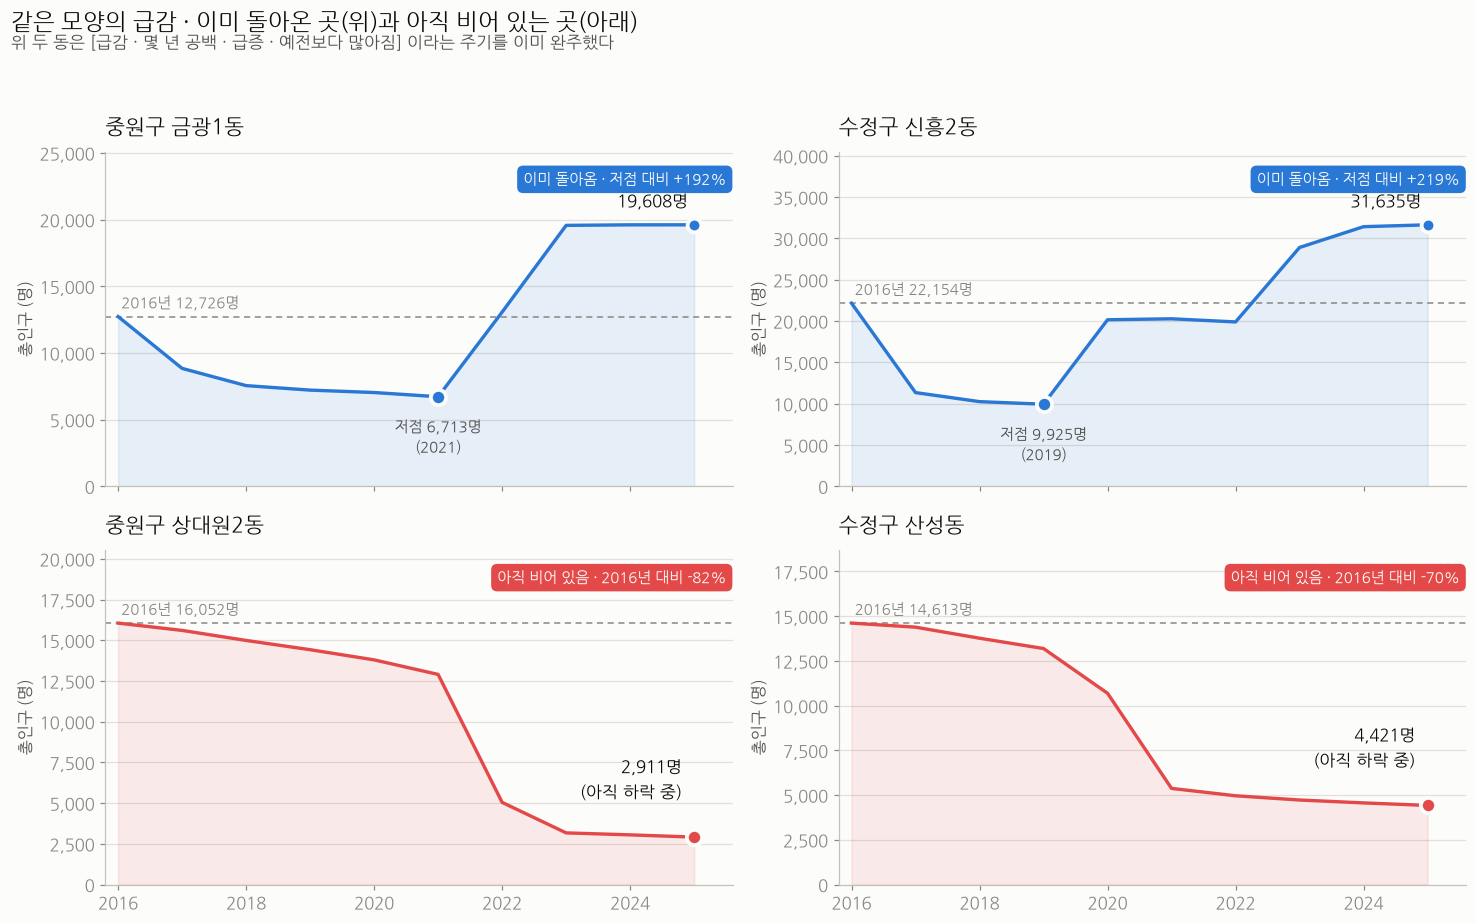

In [11]:
보기 = [('중원구', '금광1동'), ('수정구', '신흥2동'), ('중원구', '상대원2동'), ('수정구', '산성동')]

fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.4), sharex=True)
for ax, key in zip(axes.ravel(), 보기):
    s = pop_by_dong.loc[key]
    v = s.values.astype(int)
    i_min, v_min, v_end, y0 = int(np.argmin(v)), int(v.min()), int(v[-1]), int(v[0])
    완결 = i_min != len(YEARS) - 1                    # 저점이 마지막 해면 아직 바닥이 아니다
    color = C1 if 완결 else NEG

    ax.plot(YEARS, v, color=color, linewidth=2.2, zorder=3)
    ax.fill_between(YEARS, 0, v, color=color, alpha=0.10, zorder=1)
    ax.axhline(y0, color=MUTED, linewidth=1, linestyle=(0, (4, 3)), zorder=2)
    ax.annotate(f'2016년 {y0:,}명', (2016.05, y0), xytext=(0, 6), textcoords='offset points',
                fontsize=9.5, color=MUTED)

    if 완결:
        ax.plot(YEARS[i_min], v_min, 'o', color=color, markersize=10,
                markeredgecolor=SURFACE, markeredgewidth=2.5, zorder=4)
        ax.annotate(f'저점 {v_min:,}명\n({YEARS[i_min]})', (YEARS[i_min], v_min), xytext=(0, -36),
                    textcoords='offset points', ha='center', fontsize=9.5, color=INK2, linespacing=1.4)
        ax.plot(2025, v_end, 'o', color=color, markersize=9,
                markeredgecolor=SURFACE, markeredgewidth=2.5, zorder=4)
        ax.annotate(f'{v_end:,}명', (2025, v_end), xytext=(-4, 12), textcoords='offset points',
                    ha='right', fontsize=11, color=INK)
        badge = f'이미 돌아옴 · 저점 대비 +{(v_end / v_min - 1) * 100:.0f}%'
    else:
        ax.plot(2025, v_end, 'o', color=color, markersize=10,
                markeredgecolor=SURFACE, markeredgewidth=2.5, zorder=4)
        ax.annotate(f'{v_end:,}명\n(아직 하락 중)', (2025, v_end), xytext=(-8, 26),
                    textcoords='offset points', ha='right', fontsize=11, color=INK, linespacing=1.5)
        badge = f'아직 비어 있음 · 2016년 대비 {(v_end / y0 - 1) * 100:.0f}%'

    ax.text(0.99, 0.94, badge, transform=ax.transAxes, ha='right', va='top', fontsize=10,
            color=SURFACE, bbox=dict(boxstyle='round,pad=0.4', facecolor=color, edgecolor='none'))
    style(ax, f'{key[0]} {key[1]}', ylab='총인구 (명)')
    ax.set_ylim(0, max(v.max(), y0) * 1.28)
    ax.set_xticks(YEARS[::2]); ax.set_xlim(2015.8, 2025.6)
    ax.yaxis.set_major_formatter(lambda v_, p: f'{v_:,.0f}')

fig.suptitle('같은 모양의 급감 · 이미 돌아온 곳(위)과 아직 비어 있는 곳(아래)',
             fontsize=15, color=INK, x=0.008, ha='left', y=0.995)
fig.text(0.008, 0.955, '위 두 동은 [급감 · 몇 년 공백 · 급증 · 예전보다 많아짐] 이라는 주기를 이미 완주했다',
         fontsize=11, color=INK2, ha='left')
plt.tight_layout(rect=[0, 0, 1, 0.945]); plt.show()

> ## 💡 인사이트 ④ — 급감 뒤에 되돌아온 사례가 실제로 있다
>
> | 동 | 직전 최고 | 가장 적었을 때 | 2025년 | 상태 |
> |---|---|---|---|---|
> | 수정구 **신흥2동** | 22,154 | **9,925** (2019) | **31,635** | ✅ 완결 — 저점 대비 **+219%**, 예전의 1.43배 |
> | 중원구 **금광1동** | 12,726 | **6,713** (2021) | **19,608** | ✅ 완결 — 저점 대비 **+192%**, 예전의 1.54배 |
> | 중원구 **중앙동** | 17,740 | **12,093** (2021) | 16,585 | 🔶 부분 회복 (+37%) |
> | 중원구 **상대원2동** | 16,052 | **2,911** (2025) | 2,911 | ⏳ 공백 3년째 |
> | 수정구 **산성동** | 14,613 | **4,421** (2025) | 4,421 | ⏳ **공백 5년째** |
> | 분당구 **정자동** | 21,171 | **13,750** (2025) | 13,750 | ⏳ 공백 2년째 |
>
> 금광1동은 바닥(2021년 6,713명)에서 **2년 만에 19,567명**이 되어 2016년 수준을 이미 넘었습니다.
>
> **➡️ “인구가 반토막 났다”는 사실만으로 쇠퇴라고 단정하면 안 됩니다.**
> **아래 세 동은 지금 위 두 동과 똑같은 모양의 급감 구간에 있고, 아직 돌아오지 않았습니다.**
>
> ⚠️ 이 데이터에는 재개발·정비사업 정보가 없습니다. 그래서 이 주기는 **패턴으로 확인된 사실**이지만,
> “재개발 때문”은 **가설**입니다. 완주 사례도 **2건뿐**이라 “언제 몇 명이 돌아온다”는 예측은 할 수 없습니다.

## 3-3. 한 집당 사람이 가장 적은 곳은 어디인가

STEP 1에서 본 **세대당 인구 하락**(2.47 → 2.21)이 시 전역에 고르게 퍼진 것인지,
**특정 동네에 몰린 것인지** 마지막으로 확인합니다.

세대당 인구가 낮다 = **한 집에 사는 사람이 적다** = **인구는 적은데 집 수는 많다.**
계량기·고지서·봉투·민원은 집마다 생기므로, 이런 동은 **사람 한 명당 따지면 행정 수요가 더 큽니다.**

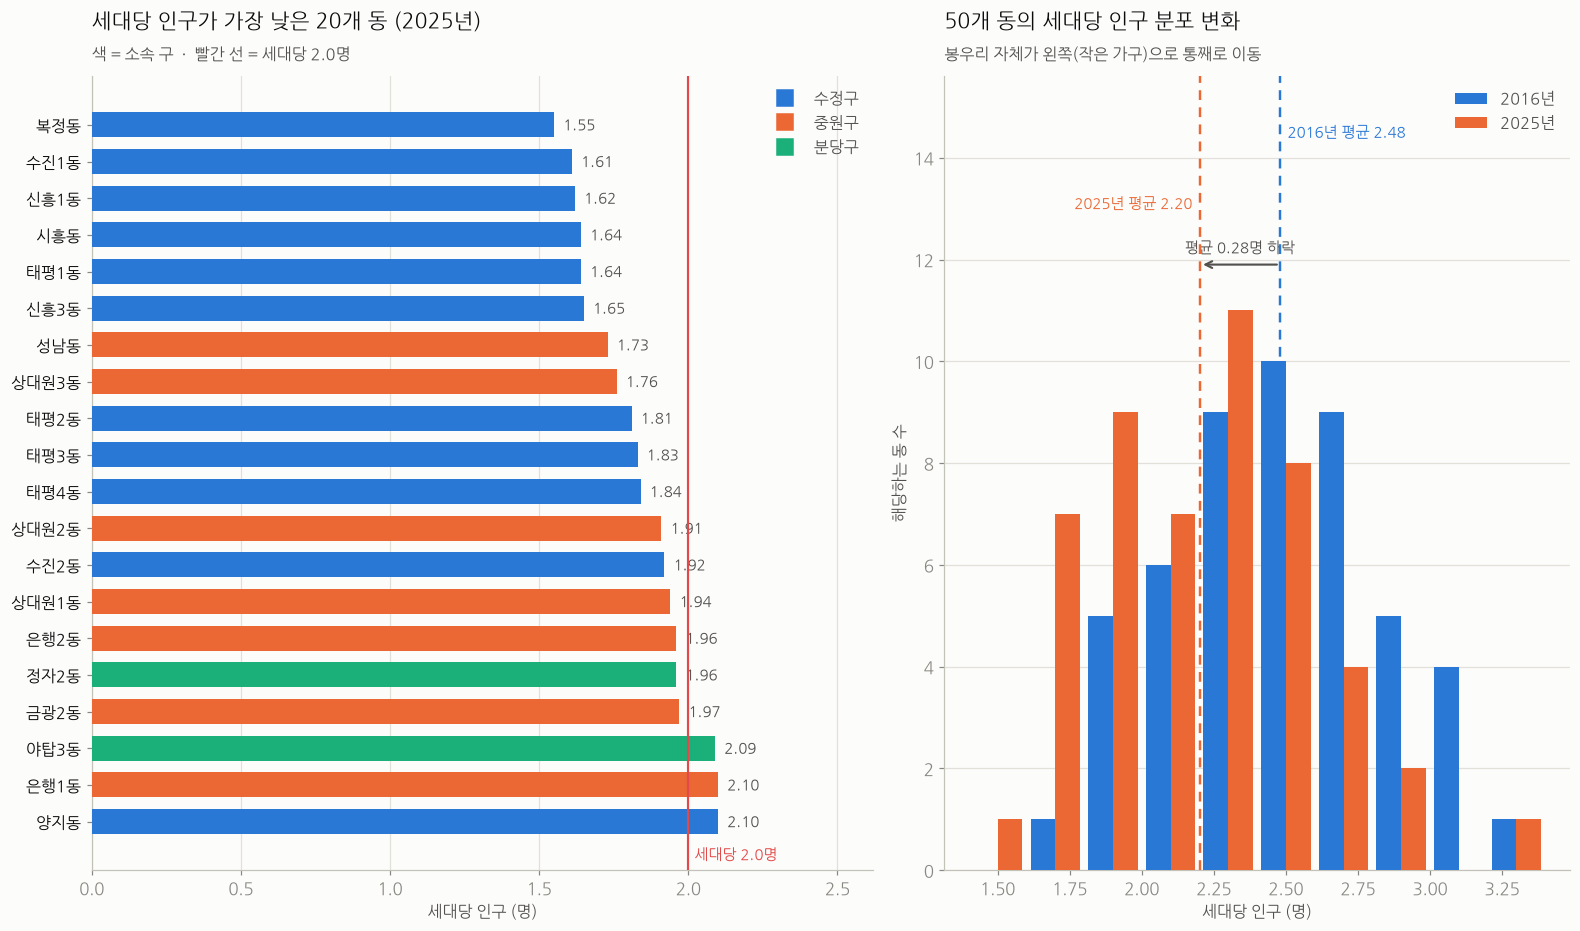

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 8.6), gridspec_kw={'width_ratios': [1.25, 1]})

# ── 왼쪽: 2025년 세대당 인구가 낮은 20개 동 ──────────────────
ax = axes[0]
low = dong.nsmallest(20, '세대당2025').sort_values('세대당2025', ascending=False)
ypos = np.arange(len(low))
ax.barh(ypos, low['세대당2025'], height=0.68, color=[GU_COLOR[g] for g in low['구']], zorder=3)
for y_, v in zip(ypos, low['세대당2025']):
    ax.annotate(f'{v:.2f}', (v, y_), xytext=(6, 0), textcoords='offset points',
                va='center', fontsize=10, color=INK2)
ax.set_yticks(ypos); ax.set_yticklabels(low['동'], fontsize=10.5, color=INK)
ax.axvline(2.0, color=NEG, linewidth=1.4, zorder=4)
ax.annotate('세대당 2.0명', (2.0, -0.9), xytext=(4, 0), textcoords='offset points',
            fontsize=10, color=NEG, va='center')
ax.set_xlim(0, 2.62)
style(ax, '세대당 인구가 가장 낮은 20개 동 (2025년)', '색 = 소속 구  ·  빨간 선 = 세대당 2.0명',
      xlab='세대당 인구 (명)', grid='x')
ax.legend(handles=[plt.Line2D([], [], marker='s', linestyle='', markersize=10,
                              color=GU_COLOR[g], label=g) for g in GU_ORDER],
          frameon=False, loc='upper right', fontsize=10.5, labelcolor=INK2)

# ── 오른쪽: 50개 동 분포가 통째로 왼쪽으로 밀렸다 ─────────────
ax = axes[1]
ax.hist([dong['세대당2016'], dong['세대당2025']], bins=np.arange(1.4, 3.6, 0.2), rwidth=0.86,
        color=[C1, C2], label=['2016년', '2025년'], zorder=3)
m16, m25 = dong['세대당2016'].mean(), dong['세대당2025'].mean()
for v, c, lab, yt, ha, dx in [(m16, C1, '2016년 평균', 14.5, 'left', 5),
                              (m25, C2, '2025년 평균', 13.1, 'right', -5)]:
    ax.axvline(v, color=c, linewidth=1.6, linestyle=(0, (4, 3)), zorder=4)
    ax.annotate(f'{lab} {v:.2f}', (v, yt), xytext=(dx, 0), textcoords='offset points',
                fontsize=10, color=c, ha=ha, va='center')
ax.annotate('', xy=(m25, 11.9), xytext=(m16, 11.9),
            arrowprops=dict(arrowstyle='->', color=INK2, linewidth=1.4))
ax.annotate(f'평균 {m16 - m25:.2f}명 하락', ((m16 + m25) / 2, 11.9), xytext=(0, 8),
            textcoords='offset points', ha='center', fontsize=10, color=INK2)
ax.set_ylim(0, 15.6)
style(ax, '50개 동의 세대당 인구 분포 변화', '봉우리 자체가 왼쪽(작은 가구)으로 통째로 이동',
      xlab='세대당 인구 (명)', ylab='해당하는 동 수')
ax.legend(frameon=False, loc='upper right', fontsize=10.5, labelcolor=INK2)

plt.tight_layout(); plt.show()

In [13]:
소가구 = dong[dong['세대당2025'] < 2.0]
print(f"세대당 인구 2.0명 미만 : {len(소가구)}개 동  {소가구['구'].value_counts().to_dict()}")
print(f"  → 세대 {소가구['세대2025'].sum():>7,} 세대 = 시 전체의 {소가구['세대2025'].sum() / hh.loc[2025] * 100:.1f}%")
print(f"  → 인구 {소가구['인구2025'].sum():>7,} 명   = 시 전체의 {소가구['인구2025'].sum() / pop.loc[2025] * 100:.1f}%")
print(f"\n세대당 인구 방향 : 하락 {(dong['세대당증감'] < 0).sum()}개 동 / 상승 {(dong['세대당증감'] > 0).sum()}개 동")

세대당 인구 2.0명 미만 : 17개 동  {'수정구': 10, '중원구': 6, '분당구': 1}
  → 세대 132,490 세대 = 시 전체의 32.4%
  → 인구 238,320 명   = 시 전체의 26.3%

세대당 인구 방향 : 하락 46개 동 / 상승 4개 동


> ## 💡 인사이트 ⑤ — 하락은 시 전역에서, 밀집은 특정 지역에서
>
> **1️⃣ 하락 자체는 거의 모든 동에서 일어났습니다.** 오른쪽 그래프에서 **봉우리가 통째로 왼쪽으로** 밀렸습니다
> (동 평균 2.48 → 2.20). **50개 중 46개 동에서 하락**, 4개 동에서만 상승했습니다.
> (상승한 4개 동 중 3개는 급감 뒤 인구가 되돌아온 동입니다 → **부록 B**)
>
> **2️⃣ 그런데 낮은 동은 한쪽에 쏠려 있습니다.** 세대당 2.0명 미만인 **17개 동** 중
> **수정구 10 · 중원구 6 · 분당구 1** — **수정·중원 구도심에 집중**되어 있습니다.
>
> **3️⃣ 그 17개 동은 “집은 많고 사람은 적은” 지역입니다.**
>
> > 📌 **시 전체 세대의 32.4%(132,490세대)가 여기 있는데, 인구 비중은 26.3%뿐입니다.**
> > **➡️ 인구를 기준으로 예산을 나누면 이 지역은 약 6%p 구조적으로 덜 받습니다.**

---
---
# 종합 — 렌즈를 세 번 당긴 결과

| | 무엇을 봤나 | 무엇이 나왔나 | 근거 수치 |
|---|---|---|---|
| **STEP 1**<br>시(市) | 인구가 줄면<br>집도 줄었나 | **아니다.**<br>사람은 줄고 **집은 늘었다** | 인구 **−68,786 (−7.06%)**<br>세대 **+15,165 (+3.85%)**<br>= 인구 효과 −27,815 + 가구 축소 효과 **+42,980** |
| **STEP 2**<br>구(區) | 세 구가<br>같은 방향인가 | **아니다.**<br>세대 증감 방향이 서로 **반대** | 수정 −0.19% / **+10.82%**<br>중원 −14.43% / −1.66%<br>분당 −6.75% / +2.93% |
| **STEP 3-1**<br>동(洞) | 어디가 비고<br>어디가 찼나 | 고르게 준 게 아니라<br>**자리바꿈**이었다 | 42개 동 **−136,977명**<br>↔ 8개 동 **+68,191명** (49.8% 상쇄) |
| **STEP 3-2** | 급감은<br>쇠퇴인가 | 반토막 뒤 **되돌아온 사례**가<br>실제로 2건 있다 | 신흥2동 저점 대비 **+219%**<br>금광1동 **+192%**<br>상대원2동·산성동·정자동은 아직 공백 |
| **STEP 3-3** | 작은 가구는<br>어디에 몰렸나 | 하락은 전역, **밀집은 국지적** | 46개 동 하락 / 4개 동 상승<br>2.0 미만 **17개 동** = 세대 **32.4%** vs 인구 26.3%<br>(수정 10 · 중원 6 · 분당 1) |

### 다섯 가지가 가리키는 방향은 하나입니다

> # 성남시의 문제는 “인구가 줄어드는 것”이 아닙니다.
> # **“줄어드는 방식이 지역마다 완전히 다르다”** 는 것입니다.
>
> 그래서 시 단위 일괄 정책이 아니라, **구청이 자기 구의 유형에 맞춰 집행하는 정책**이 필요합니다.

---
# 제안 — 구청 단위 실행안 2건

앞의 분석에서 **성격이 완전히 다른 두 개의 문제**가 나왔습니다.

| | 문제 | 근거 | 주관 |
|---|---|---|---|
| **정책 1** | 집은 늘었는데 **배분 기준은 아직 사람 수** | 인사이트 ①·②·⑤ | 수정구청 · 중원구청 |
| **정책 2** | **지금 비어 있는 동네가 곧 다시 찬다** | 인사이트 ③·④ | 중원구청 · 수정구청 |

## 📋 정책 1 — 생활서비스 배분 기준을 ‘인구’에서 **‘세대’** 로

**무엇이 문제인가.** 수정구는 10년간 인구가 **−452명(−0.19%)**, 사실상 그대로인데 세대는 **+11,345(+10.82%)** 늘었습니다.
인구 기준으로 나누면 **수정구 몫은 10년째 그대로**지만, 봉투·계량·고지서·민원은 집마다 생기므로 **실제 수요는 11% 늘었습니다.**
여기에 세대당 2.0명 미만 17개 동은 **세대 32.4% vs 인구 26.3%** 로, 인구 기준 배분에서 **약 6%p 덜 받고 있습니다.**

**대상을 고를 때 한 가지만 걸러냅니다.** 세대당 인구가 낮은 데는 성격이 다른 두 가지가 섞여 있습니다.

| 성격 | 특징 | 어느 정책 대상인가 |
|---|---|---|
| **(A) 소가구 밀집** | 세대는 유지·증가하는데 한 집당 사람이 적다 | **정책 1** |
| **(B) 재개발 공백** | 세대 자체가 사라져 남은 표본이 작다 | **정책 2** (아래 코드에서 제외) |

**실행안**

| 순위 | 대상 | 조치 |
|---|---|---|
| **1순위**<br>세대당 1.8명 미만 | **수정구청 6개 동** — 복정동(1.55) · 수진1동(1.61) · 신흥1동(1.62) · 태평1동(1.64) · 시흥동(1.64) · 신흥3동(1.65)<br>**중원구청 2개 동** — 성남동(1.73) · 상대원3동(1.76) | ① 소용량(5·10L) 종량제봉투 **상시 취급 의무화**<br>② 1·2인 가구용 음식물 **소량 배출 단말 증설**<br>③ 주민센터 창구 인력 산정식을 인구 → **세대 기준**으로 변경 |
| **2순위**<br>세대당 1.8~2.0명 | 수정구청 4 · 중원구청 3 · 분당구청 1 (아래 표) | 1순위 시행 후 순차 적용<br>분당구는 구 평균이 2.43으로 여유가 있어 **연 1회 재측정만** |

**성과 측정** — 동별 `세대수 ÷ 생활서비스 접점 수`의 구 내 편차 축소, **3년 후 세대당 인구 재측정**(계속 하락하면 대상 확대).

⚠️ 세대당 인구가 **오른 4개 동 중 3개(신흥2동·고등동·금광1동)는 급감 뒤 인구가 되돌아온 동**입니다.
즉 **새 입주는 이 지표를 되돌릴 수 있습니다.**
→ 대상 동에 대규모 입주가 예정되면 **재측정 후 대상에서 빼는 절차**를 함께 둬야 합니다.

In [14]:
# (A) 소가구 밀집 vs (B) 재개발 공백 을 갈라서 정책 1 대상만 남긴다
후보 = dong[dong['세대당2025'] < 2.0].copy()
후보['성격']   = np.where(후보['세대변화율'] < -20, '(B) 재개발 공백', '(A) 소가구 밀집')
후보['우선순위'] = np.where(후보['세대당2025'] < 1.8, '1순위', '2순위')

대상 = 후보[후보['성격'] == '(A) 소가구 밀집'].sort_values(['우선순위', '세대당2025'])
제외 = 후보[후보['성격'] != '(A) 소가구 밀집']

print(f"세대당 2.0 미만          : {len(후보)}개 동")
print(f"  (B) 재개발 공백 → 제외 : {list(제외['동'])}  (세대 {제외['세대변화율'].iloc[0]:.1f}%)")
print(f"  (A) 소가구 밀집 → 대상 : {len(대상)}개 동, {대상['세대2025'].sum():,} 세대 "
      f"(시 전체 세대의 {대상['세대2025'].sum() / hh.loc[2025] * 100:.1f}%)\n")
print(대상.groupby(['우선순위', '구']).size().to_string())

대상[['구', '동', '우선순위', '세대2025', '세대당2025', '세대변화율']].round(2).reset_index(drop=True)

세대당 2.0 미만          : 17개 동
  (B) 재개발 공백 → 제외 : ['상대원2동']  (세대 -80.0%)
  (A) 소가구 밀집 → 대상 : 16개 동, 130,967 세대 (시 전체 세대의 32.0%)

우선순위  구  
1순위   수정구    6
      중원구    2
2순위   분당구    1
      수정구    4
      중원구    3


,구,동,우선순위,세대2025,세대당2025,세대변화율
0,수정구,복정동,1순위,6734,1.55,-2.28
1,수정구,수진1동,1순위,6682,1.61,-8.43
2,수정구,신흥1동,1순위,7440,1.62,-4.28
3,수정구,태평1동,1순위,8221,1.64,-8.65
4,수정구,시흥동,1순위,2162,1.64,55.99
5,수정구,신흥3동,1순위,6452,1.65,10.52
6,중원구,성남동,1순위,18409,1.73,27.20
7,중원구,상대원3동,1순위,6275,1.76,-3.10
8,수정구,태평2동,2순위,7529,1.81,-1.45
9,수정구,태평3동,2순위,6314,1.83,-7.69


## 📋 정책 2 — 급감 동은 **‘회복 가능성 검토’를 거친 뒤에만** 시설을 줄인다

**무엇이 문제인가.** 중원구 인구 **−34,337명**(시 감소분의 49.9%)만 보면 *“쇠퇴하니 시설을 줄이자”* 는 결론이 쉽게 나옵니다.
그런데 **금광1동**은 2021년 6,713명(−47%)까지 떨어졌다가 **2년 뒤 19,567명**이 됐습니다.
만약 2021년에 어린이집·학급·수거 차량을 줄였다면 **2년 뒤 인구가 3배가 된 동에서 서비스 공백**이 터졌을 것입니다.

**그리고 지금, 세 개 동이 같은 구간에 있습니다.**

| 동 | 직전 최고 | 2025년 | 감소폭 | 급감 시작 | 경과 |
|---|---|---|---|---|---|
| 중원구 **상대원2동** | 16,052 | **2,911** | **−81.9%** | 2022년 | 3년째 |
| 수정구 **산성동** | 14,613 | **4,421** | **−69.7%** | 2020년 | **5년째** |
| 분당구 **정자동** | 21,171 | **13,750** | −35.1% | 2023년 | 2년째 |

**실행안 — 예측이 아니라 ‘검토 의무’로 설계합니다.** 완주 사례가 2건뿐이라 “언제 몇 명이 들어온다”고 예측하지 않습니다.
대신 **급감을 쇠퇴로 단정하지 못하게 하는 절차**를 둡니다.

| 주관 | 대상 | 조치 |
|---|---|---|
| **양 구청 공통** | 급감 동 전체 | ① 시설 감축 결정 시 **“저점 대비 회복률”을 의무 검토 항목으로 추가**<br>② 감축 대신 **인접 동으로 인력·예산 탄력 전환**, 회복 신호(전년비 +20% 이상) 확인 시 **자동 환원**하는 규칙을 사전 문서화 |
| **중원구청** | 상대원2동 | 인접 **상대원1동**과 학군·수거 권역을 **가변 운영**으로 설계 |
| **수정구청** | 산성동 | 동일 적용. **공백 5년째로 가장 오래되어** 우선 점검 |
| **분당구청**(참고) | 정자동 | 회복 신호가 아직 없음 → 중원·수정의 실측 사례를 **비교 기준**으로만 활용 |

**성과 측정** — 감축 결정 중 회복률 검토를 거친 비율(목표 100%), 회복 신호 후 증설까지 걸린 기간.

⚠️ **어디까지만 뒷받침되는가** — 급감이 경계 조정이 아니라 실제 인구 이동임은 확인했습니다(부록 A).
하지만 **“떠난 사람이 돌아온다”는 확인되지 않았습니다.** n=2는 예측 근거로 부족하고, 이 CSV에는 정비사업 일정이 없습니다.
**집행 전 실제 사업 일정과 반드시 대조해야 합니다.**

---
# 한계 — 이 데이터로 말할 수 없는 것

정책에 쓰려면 **확인된 것과 확인되지 않은 것**을 분명히 갈라야 합니다.

### ❌ 말할 수 없는 것

| 한계 | 그래서 무엇을 못 하나 |
|---|---|
| **연령 정보 없음** | 세대당 인구 하락이 *고령 1인가구*인지 *청년 1인가구*인지 *자녀 분가*인지 **구분 불가**<br>→ 정책 1의 세부 설계(돌봄 vs 주거)를 정하려면 **연령별 통계를 추가 확보해야 함** |
| **전입·전출 정보 없음** | “A동이 B동 인구를 흡수했다”고 말할 수 없음. **각 동의 증감만** 확인 가능 |
| **원인 정보 없음**<br>(재개발·주택 공급) | 인사이트 ④의 주기는 **패턴으로 확인된 사실**이지만 “재개발 때문”은 **가설**<br>→ 정책 2 집행 전 **실제 사업 일정과 대조 필요** |
| **완주 사례 2건뿐** | 예측 근거로 부족 → 정책 2를 ‘예측’이 아니라 **‘검토 의무’로 설계한 이유** |
| **분류·검사의 흔들림** | 4분면에서 한 축이 ±2% 이내인 동 **11개(22%)** → 유형별 동 수는 **근사치**<br>경계 조정 검사를 적용 못 한 동 **24개(48%)** (부록 A·B) |
| **주민등록 · 연말 스냅샷** | 실거주가 아니고 등록외국인 제외, 각 연도 **12월 말** 값이라 연중 변동은 안 보임 |

### ✅ 반대로, 확실하게 말할 수 있는 것

| # | 확인된 사실 | 어떻게 확인했나 |
|---|---|---|
| 1 | 인구는 줄고(−68,786) 세대는 늘었다(+15,165) | 항등식 검증 통과 · 10개 연도 전 구간 일치 |
| 2 | 세 구의 변화 방향이 서로 다르다 | 계층 합계 검증 통과 (동합 = 구합 = 시) |
| 3 | 42개 동 −136,977명, 8개 동 +68,191명 | 동 합계 = 시 합계 확인 *(둘 사이 이동 여부는 알 수 없음)* |
| 4 | 두 개 동에서 급감 → 회복이 실제로 관측됐다 | 연도별 경계 조정 검사 통과 (부록 A) |
| 5 | 세대당 인구 46개 동 하락 / 4개 동 상승 | `세대당 인구 = 인구 ÷ 세대` 항등식 확인 |

> 위 다섯 가지는 **이 CSV 한 개 파일 안에서 스스로 검증**되었고,
> **두 정책은 모두 이 다섯 가지 위에만 서 있습니다.**

---
---
# 부록 A. 급감이 ‘진짜 인구 이동’인지 검사한 방법

> 본문 **STEP 3-2** 에서 쓴 검사입니다. 흐름을 끊지 않으려고 여기로 뺐습니다.

인구가 1년 만에 절반이 되는 구간에는 두 가지 가능성이 있습니다.

1. **진짜로 사람이 오갔다**
2. **행정동 경계를 다시 그었다** (사람은 그대로인데 소속만 바뀜)

둘은 이렇게 갈라집니다.

> 경계만 다시 그은 것이라면 **바로 그 해에** 이 동에서 빠진 만큼 **옆 동이 늘어납니다.**
> 그러면 **인접 동을 묶은 그 해 합계는 거의 움직이지 않습니다.**
>
> ```
> 잔존율 = 그 해 묶음 합계 증감 ÷ 그 해 해당 동 증감
>
>   1에 가까움 → 묶음도 같이 움직였다  = 실제 인구 이동
>   0에 가까움 → 묶음은 그대로였다     = 경계 조정 의심
> ```
>
> 📌 경계 조정은 **특정 1개 연도**에 일어나므로 10년 끝점끼리 비교하면 안 되고 **연도별로** 봐야 합니다.

In [15]:
묶음 = {
    '신흥1~3동': ['신흥1동', '신흥2동', '신흥3동'],
    '복정+위례': ['복정동', '위례동'],
    '산성+단대+양지': ['산성동', '단대동', '양지동'],
    '신촌+고등+시흥': ['신촌동', '고등동', '시흥동'],
    '금광1~2동': ['금광1동', '금광2동'],
    '상대원1~3동': ['상대원1동', '상대원2동', '상대원3동'],
    '성남동+중앙동': ['성남동', '중앙동'],
    '정자동+정자1~3동': ['정자동', '정자1동', '정자2동', '정자3동'],
    '판교권(판교·삼평·백현·운중)': ['판교동', '삼평동', '백현동', '운중동'],
}
by_dong = pop_by_dong.reset_index().set_index('동')
소속 = {d_: g for g, ms in 묶음.items() for d_ in ms}

판정 = []
for d_, g in 소속.items():
    s = by_dong.loc[d_, YEARS]
    for i in range(1, len(YEARS)):
        본인 = int(s.iloc[i] - s.iloc[i-1])
        # 작은 동의 미세한 흔들림이 비율을 왜곡하지 않도록 최소 크기 조건
        if abs(본인) < 1000 or abs(본인) / s.iloc[i-1] < 0.05:
            continue
        묶음증감 = int(by_dong.loc[묶음[g], YEARS[i]].sum() - by_dong.loc[묶음[g], YEARS[i-1]].sum())
        잔존율 = 묶음증감 / 본인
        판정.append({'구': by_dong.loc[d_, '구'], '동': d_, '연도': YEARS[i], '묶음': g,
                     '해당 동 증감': 본인, '묶음 증감': 묶음증감, '잔존율': round(잔존율, 2),
                     '판정': '경계 조정 의심' if abs(잔존율) < 0.3 else '실제 인구 이동'})

판정 = pd.DataFrame(판정).sort_values('잔존율').reset_index(drop=True)
의심 = 판정[판정['판정'] == '경계 조정 의심']
print(f"검사 대상(전년비 5% 이상 & 1,000명 이상 변동, 묶음 소속) : {len(판정)}건")
print(f"  실제 인구 이동 : {len(판정) - len(의심)}건")
print(f"  경계 조정 의심 : {len(의심)}건 → {sorted(set(의심['동']))} ({sorted(set(의심['연도']))})\n")
print(f"※ 한계 : 묶음을 정의할 수 없어 이 검사를 적용하지 못한 동이 {50 - len(소속)}개 "
      f"({(50 - len(소속)) / 50 * 100:.0f}%) 있다.")
판정.head(8)

검사 대상(전년비 5% 이상 & 1,000명 이상 변동, 묶음 소속) : 30건
  실제 인구 이동 : 28건
  경계 조정 의심 : 2건 → ['성남동', '중앙동'] ([2017])

※ 한계 : 묶음을 정의할 수 없어 이 검사를 적용하지 못한 동이 24개 (48%) 있다.


,구,동,연도,묶음,해당 동 증감,묶음 증감,잔존율,판정
0,분당구,정자3동,2021,정자동+정자1~3동,1037,-485,-0.47,실제 인구 이동
1,중원구,성남동,2017,성남동+중앙동,1670,-344,-0.21,경계 조정 의심
2,중원구,중앙동,2017,성남동+중앙동,-2014,-344,0.17,경계 조정 의심
3,수정구,신흥2동,2024,신흥1~3동,2516,2071,0.82,실제 인구 이동
4,분당구,운중동,2024,판교권(판교·삼평·백현·운중),2626,2148,0.82,실제 인구 이동
5,수정구,고등동,2021,신촌+고등+시흥,1871,1545,0.83,실제 인구 이동
6,수정구,위례동,2018,복정+위례,2918,2460,0.84,실제 인구 이동
7,중원구,중앙동,2022,성남동+중앙동,4112,3627,0.88,실제 인구 이동


**읽는 법.** 2017년 성남동은 **+1,670명**, 중앙동은 **−2,014명**인데 두 동을 묶은 합계는 **−344명**으로 거의 그대로였습니다.
한쪽에서 빠진 만큼 옆 동이 받은 **전형적인 경계 조정 신호**입니다.
→ 그래서 **성남동·중앙동의 2017년 전후 개별 변화율은 단독 근거로 쓰지 않았습니다.**
(다만 중앙동의 **2022년 +4,112명은 잔존율 0.88로 실제 인구 이동** — 별개 사건입니다.)

⚠️ 이 검사는 **“경계 조정이 아니다”** 까지만 말해 줍니다. **“떠난 사람이 돌아온다”** 는 말해 주지 않습니다.

---
# 부록 B. 4분면 분류가 말해주지 않는 것 두 가지

> 본문 **STEP 3-1 · 3-3** 의 각주입니다.

**1️⃣ “가구 통합형 0개”는 “가구가 합쳐진 적 없다”는 뜻이 아닙니다.**
4분면은 **인구 방향 × 세대 방향**만 봅니다. 세대당 인구가 오르내리는 것은 **아예 측정하지 않습니다.**
실제로 **4개 동에서 세대당 인구가 올랐고**, 그중 3개는 재입주가 끝난 동입니다.

**2️⃣ 0% 기준선에 아슬아슬하게 걸친 동이 있습니다.**
예를 들어 야탑1동은 세대가 7,527 → 7,545, 단 **+18세대(+0.24%)** 차이로 ‘가구분화형’이 됩니다.
**유형별 동 수와 합계는 이 정도 흔들림을 감안하고 읽어야 합니다.**

In [16]:
오름 = dong[dong['세대당증감'] > 0]
print(f"[세대당 인구 상승] {len(오름)}개 동")
print(오름[['구', '동', '세대당2016', '세대당2025', '인구변화율', '세대변화율', '유형']]
      .round(2).to_string(index=False))

경계 = dong[(dong['인구변화율'].abs() < 2) | (dong['세대변화율'].abs() < 2)]
print(f"\n[경계 민감도] 한 축이 ±2% 이내인 동 : {len(경계)}개 / 50개 "
      f"→ 기준선을 조금만 옮겨도 유형이 바뀐다")
print(경계[['구', '동', '인구변화율', '세대변화율', '유형']].round(2).to_string(index=False))

[세대당 인구 상승] 4개 동
  구    동  세대당2016  세대당2025  인구변화율  세대변화율    유형
수정구 신흥2동     2.44     2.57  42.80  35.64 신규유입형
수정구  고등동     1.99     2.22 584.68 513.61 신규유입형
중원구  중앙동     2.07     2.21  -6.51 -12.24 동반축소형
중원구 금광1동     2.22     2.38  54.08  43.75 신규유입형

[경계 민감도] 한 축이 ±2% 이내인 동 : 11개 / 50개 → 기준선을 조금만 옮겨도 유형이 바뀐다
  구    동  인구변화율  세대변화율    유형
수정구 태평2동 -18.76  -1.45 동반축소형
수정구  단대동 -16.73  -1.80 동반축소형
수정구  양지동 -16.17  -1.11 동반축소형
중원구 하대원동 -13.04   1.66 가구분화형
분당구 수내1동  -1.37   9.38 가구분화형
분당구 정자1동  -1.70   5.93 가구분화형
분당구 정자3동  -0.76   7.98 가구분화형
분당구 이매1동 -10.43  -1.05 동반축소형
분당구 야탑1동 -10.78   0.24 가구분화형
분당구 야탑3동 -15.15  -1.77 동반축소형
분당구  금곡동 -11.41  -1.20 동반축소형
